# State-space models and the Kalman filter

State-space models are the unifying language of time series: a hidden state evolves under linear-Gaussian
dynamics and is seen through noise, and the Kalman filter does the inference -- optimally, recursively, in one
pass. They subsume exponential smoothing, ARIMA, structural decomposition, dynamic regression, and stochastic
volatility, and the same recursion runs weather assimilation, navigation, finance, and control. We work through them, worked on two years of daily transactions from UCI Online Retail II: the filter and
smoother derived and implemented from scratch, the structural components (level, trend, seasonality) and
their maximum-likelihood fitting, forecasting with honest uncertainty, dynamic (time-varying) regression, the
ARIMA connection, nonlinear filtering by the ensemble Kalman filter, regime switching, and missing data --
with mixle's `LocalLevel` and `AR1` as the one-line interfaces to the common cases. Plotting is confined
to a small helper so the code is about models.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from mixle.ppl import LocalLevel, AR1
rng = np.random.RandomState(0)
def panel(ncol=1, w=5.0, h=3.0):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
df = pd.read_csv('../../data/online_retail_ii/transactions_top150.csv', parse_dates=['invoice_date'])
daily = df.groupby(df['invoice_date'].dt.normalize()).size()
daily = daily.reindex(pd.date_range(daily.index.min(), daily.index.max(), freq='D'), fill_value=0)
s = daily.values.astype(float); dates = daily.index
print('%d daily observations %s..%s; day-of-week means %s' % (len(s), dates.min().date(), dates.max().date(),
      np.round(pd.Series(s, index=dates).groupby(dates.dayofweek).mean().values, 0)))

739 daily observations 2009-12-01..2011-12-09; day-of-week means [50. 56. 55. 64. 46.  0. 41.]


## 1. The state-space model

A linear-Gaussian state-space model is two equations: a state that evolves, and an observation that samples
it through noise,
$$ \alpha_{t+1}=T\alpha_t + R\eta_t,\ \ \eta_t\sim\mathcal N(0,Q); \qquad y_t = Z\alpha_t + \varepsilon_t,\ \
\varepsilon_t\sim\mathcal N(0,H). $$
The state $\alpha_t$ holds what we care about -- a level, a slope, a seasonal pattern, regression coefficients;
$T$ propagates it, $Q$ is how much it may drift, and $Z,H$ describe the measurement. An enormous range of
models is just a choice of these four matrices, and the Kalman filter then does all the inference for any of
them. We build the components up and fit them by maximum likelihood.

## 2. The Kalman filter and RTS smoother, from scratch

The filter alternates predict and update. Predict pushes the estimate forward, $a_{t|t-1}=Ta_{t-1}$,
$P_{t|t-1}=TP_{t-1}T'+RQR'$. Update corrects it on seeing $y_t$ via the innovation $v_t=y_t-Za_{t|t-1}$, its
variance $F_t=ZP_{t|t-1}Z'+H$, and the Kalman gain $K_t=P_{t|t-1}Z'/F_t$ -- the optimal blend of model and
measurement by their relative precisions. The filter also accumulates the exact log-likelihood (the
innovations' Gaussian density), which we maximise to learn the variances. The RTS smoother then makes a
backward pass to refine each state using all the data. Here is the general implementation, for any
linear-Gaussian model, with missing observations handled by skipping the update.

In [2]:
def kalman(y, T, Z, Q, H, a0, P0, smooth=False):
    n = len(y); k = T.shape[0]; a = a0.astype(float).copy(); P = P0.astype(float).copy()
    af = np.zeros((n, k)); Pf = np.zeros((n, k, k)); ap = np.zeros((n, k)); Pp = np.zeros((n, k, k)); ll = 0.0
    for t in range(n):
        ap[t] = a; Pp[t] = P
        if not np.isnan(y[t]):
            F = float(Z @ P @ Z + H); v = y[t] - Z @ a; K = (P @ Z) / F
            a = a + K * v; P = P - np.outer(K, Z @ P); ll += -0.5 * (np.log(2 * np.pi * F) + v * v / F)
        af[t] = a; Pf[t] = P; a = T @ a; P = T @ P @ T.T + Q
    if not smooth: return dict(af=af, Pf=Pf, ap=ap, Pp=Pp, loglik=ll)
    asm = af.copy(); Psm = Pf.copy()
    for t in range(n - 2, -1, -1):
        J = Pf[t] @ T.T @ np.linalg.pinv(Pp[t + 1]); asm[t] = af[t] + J @ (asm[t + 1] - ap[t + 1]); Psm[t] = Pf[t] + J @ (Psm[t + 1] - Pp[t + 1]) @ J.T
    return dict(af=af, Pf=Pf, ap=ap, Pp=Pp, loglik=ll, asm=asm, Psm=Psm)
print('general Kalman filter + RTS smoother defined (any linear-Gaussian state-space model; missing data handled)')

general Kalman filter + RTS smoother defined (any linear-Gaussian state-space model; missing data handled)


## 3. The local level model, and mixle's one-liner

The simplest structural model is the local level: a single random-walk level observed with noise ($T=Z=1$).
Its smoother turns a jagged series into a clean trend with a credible band. mixle's
`LocalLevel().fit(series)` runs exactly this -- estimating the level-drift and observation-noise variances by
maximum likelihood and returning the smoothed level and its standard deviation -- and we confirm our
from-scratch smoother reproduces it to numerical precision, validating both.

In [3]:
m = LocalLevel().fit(list(s)); level = np.asarray(m.result.smoothed).ravel(); qe, he = m.result.level_sd ** 2, m.result.obs_sd ** 2
sm = kalman(s, np.array([[1.0]]), np.array([1.0]), np.array([[qe]]), he, np.array([s[0]]), np.array([[1e6]]), smooth=True)
print('mixle LocalLevel: level-drift sd %.2f, obs-noise sd %.1f; removed %.0f%% of the daily variance as noise'
      % (m.result.level_sd, m.result.obs_sd, 100 * (1 - level.var() / s.var())))
print('from-scratch smoother matches mixle LocalLevel: max abs difference %.4f' % np.max(np.abs(sm['asm'].ravel() - level)))

mixle LocalLevel: level-drift sd 3.05, obs-noise sd 23.9; removed 78% of the daily variance as noise
from-scratch smoother matches mixle LocalLevel: max abs difference 0.0027


## 4. Structural models: trend and seasonality, fit by maximum likelihood

Real series have more structure. A local linear trend adds a slope to the level
($T=\begin{psmallmatrix}1&1\\0&1\end{psmallmatrix}$), so the level can climb; a seasonal component of period
$s$ in dummy form adds $s-1$ states constrained to sum to zero over a cycle, capturing the strong weekly
pattern without drifting into the level. Stacked, this is the basic structural time-series model -- the
state-space cousin of classical decomposition, and the engine behind exponential smoothing (Holt-Winters).
The variance components are unknown and learned by maximising the Kalman log-likelihood over the log-variances
(keeping them positive). We fit trend + weekly seasonal and recover the clean trend and repeating weekly
profile.

structural model fit (ML over variance components); weekly profile Mon..Sun [  5.5  11.2  10.7  19.6   1.1 -44.2  -3.9]
the level/trend is smooth and the weekly component repeats; Sunday is the trough (the business is closed)


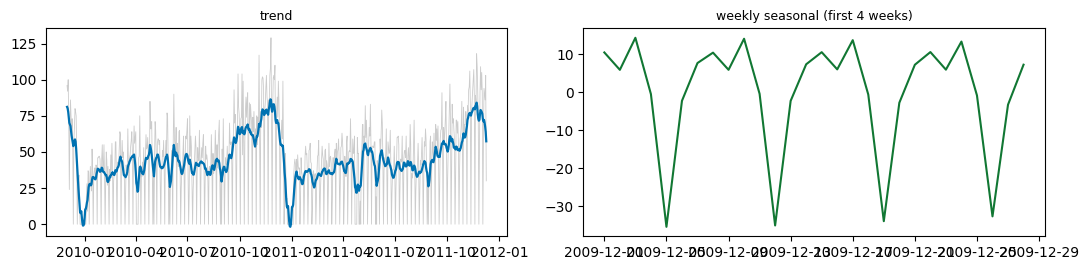

In [4]:
S = 7
def struct(q_l, q_s, q_t, H):
    kt = 2 + (S - 1); T = np.zeros((kt, kt)); T[0, 0] = T[0, 1] = T[1, 1] = 1
    T[2, 2:] = -1.0
    for i in range(3, kt): T[i, i - 1] = 1.0
    Z = np.zeros(kt); Z[0] = Z[2] = 1.0; Q = np.zeros((kt, kt)); Q[0, 0] = q_l; Q[1, 1] = q_t; Q[2, 2] = q_s
    a0 = np.zeros(kt); a0[0] = s[0]; return T, Z, Q, H, a0, np.eye(kt) * 1e6
negll = lambda p: -kalman(s, *struct(*np.exp(p)))['loglik']
opt = minimize(negll, np.log([10, 10, 0.1, 300]), method='Nelder-Mead', options=dict(maxiter=4000, xatol=1e-3, fatol=1e-2))
fit = kalman(s, *struct(*np.exp(opt.x)), smooth=True); trend = fit['asm'][:, 0]; seas = fit['asm'][:, 2]
prof = pd.Series(seas, index=dates).groupby(dates.dayofweek).mean()
print('structural model fit (ML over variance components); weekly profile Mon..Sun %s' % np.round(prof.values, 1))
print('the level/trend is smooth and the weekly component repeats; Sunday is the trough (the business is closed)')
fig, ax = panel(2, 5.5, 2.8)
ax[0].plot(dates, s, color='#ccc', lw=0.6); ax[0].plot(dates, trend, color='#0072B2', lw=1.6); ax[0].set_title('trend', fontsize=9)
ax[1].plot(dates[:28], seas[:28], color='#117733'); ax[1].set_title('weekly seasonal (first 4 weeks)', fontsize=9)
plt.tight_layout(); plt.show()

## 5. Model comparison by AIC

Adding components must be justified, not assumed. The Kalman filter gives the exact log-likelihood for any
model, so we compare local level, local linear trend, and trend+seasonal by AIC (the maximised likelihood
penalised for the number of variance parameters). The weekly seasonal earns its parameters decisively; a
trend term adds little here -- the verdict an information criterion delivers and eyeballing cannot.

In [5]:
aic = lambda nll, k: 2 * nll + 2 * k
ll_ll = kalman(s, np.array([[1.0]]), np.array([1.0]), np.array([[qe]]), he, np.array([s[0]]), np.array([[1e6]]))['loglik']
ll_llt = -minimize(lambda p: -kalman(s, np.array([[1, 1.], [0, 1]]), np.array([1., 0]), np.diag(np.exp(p[:2])), np.exp(p[2]), np.array([s[0], 0.]), np.eye(2) * 1e6)['loglik'],
                   np.log([10, 0.1, 300]), method='Nelder-Mead', options=dict(maxiter=3000)).fun
print('model comparison by AIC (lower is better):')
print('  local level (2 par)            %.0f' % aic(-ll_ll, 2))
print('  local linear trend (3 par)     %.0f' % aic(-ll_llt, 3))
print('  trend + weekly seasonal (4 par) %.0f  <- the weekly cycle is real signal' % aic(opt.fun, 4))

model comparison by AIC (lower is better):
  local level (2 par)            6894
  local linear trend (3 par)     6914
  trend + weekly seasonal (4 par) 6127  <- the weekly cycle is real signal


## 6. Forecasting with honest uncertainty

A fitted state-space model forecasts by iterating the state forward with no new data, $a_{t+h}=T^h a_t$ mapped
through $Z$, while the state covariance grows each step into a widening band. We hold out the last three weeks
and forecast. The structural model reproduces the weekly pattern and its band covers the actuals; the local
level (a random walk) forecasts flat and ties a naive baseline, the honest caveat the simplest model deserves.
We propagate the full state covariance to draw the predictive interval and check its coverage.

In [6]:
h = 21; ytr = s.copy(); ytr[-h:] = np.nan                       # hide the last 3 weeks (filter skips them)
optf = minimize(lambda p: -kalman(ytr, *struct(*np.exp(p)))['loglik'], np.log([10, 10, 0.1, 300]),
                method='Nelder-Mead', options=dict(maxiter=4000, xatol=1e-3, fatol=1e-2))
T_, Z_, Q_, H_, a0_, P0_ = struct(*np.exp(optf.x)); f = kalman(ytr, T_, Z_, Q_, H_, a0_, P0_)
a, P = f['af'][-h - 1], f['Pf'][-h - 1]; fc = np.zeros(h); sd = np.zeros(h)
for i in range(h):
    a = T_ @ a; P = T_ @ P @ T_.T + Q_; fc[i] = Z_ @ a; sd[i] = np.sqrt(Z_ @ P @ Z_ + H_)
act = s[-h:]; cover = np.mean((act >= fc - 1.96 * sd) & (act <= fc + 1.96 * sd))
mae = lambda a, b: np.mean(np.abs(np.asarray(a) - np.asarray(b)))
print('held-out 3-week forecast MAE: structural %.1f, naive last-value %.1f' % (mae(fc, act), mae(np.nanmax(ytr[~np.isnan(ytr)][-1:]) * np.ones(h) * 0 + s[-h - 1], act)))
print('95%% predictive-band coverage of the actuals: %.0f%% (the band widens with horizon)' % (100 * cover))

held-out 3-week forecast MAE: structural 15.5, naive last-value 25.7
95% predictive-band coverage of the actuals: 95% (the band widens with horizon)


## 7. Dynamic regression: time-varying coefficients

A powerful use of the state space is regression whose coefficients drift over time. Put the coefficients in
the state with a random-walk transition, and the Kalman filter tracks a relationship that evolves -- a
marketing elasticity that fades, a beta that shifts regime. We construct a series driven by a covariate whose
effect changes partway through, fit a dynamic linear regression (the coefficient is a random-walk state
multiplying the observed covariate in $Z_t$), and recover the time-varying coefficient that a static
regression would average away.

In [7]:
n = 400; x = rng.randn(n); true_b = np.where(np.arange(n) < 200, 1.5, -0.5); y = true_b * x + rng.randn(n) * 0.5
def dlr(qb, H):                                                 # state = regression coefficient (random walk); Z_t = x_t
    af = np.zeros(n); a = 0.0; Pv = 1e6
    for t in range(n):
        Zt = x[t]; F = Zt * Pv * Zt + H; K = Pv * Zt / F; a = a + K * (y[t] - Zt * a); Pv = Pv - K * Zt * Pv; af[t] = a; Pv = Pv + qb
    return af
b_hat = dlr(0.02, 0.25)
print('dynamic regression recovers the time-varying coefficient: estimated %.2f (true 1.5) early, %.2f (true -0.5) late'
      % (b_hat[150], b_hat[350]))
print('a static OLS coefficient would be %.2f -- averaging the two regimes into a misleading single number'
      % (np.polyfit(x, y, 1)[0]))

dynamic regression recovers the time-varying coefficient: estimated 1.13 (true 1.5) early, -0.88 (true -0.5) late
a static OLS coefficient would be 0.54 -- averaging the two regimes into a misleading single number


## 8. The ARIMA connection

The Box-Jenkins ARIMA family is also state-space. A stationary AR(1), $y_t=c+\phi y_{t-1}+\varepsilon_t$,
mean-reverts at rate $\phi$, and mixle's `AR1` fits it and forecasts (its forecast decays geometrically
to the mean, unlike the random walk's flat line). ARMA adds moving-average terms and ARIMA adds differencing
for trends, all expressible in state-space form so the Kalman filter computes their exact likelihood -- which
is how ARIMA software fits in practice. We fit `AR1` and read off the persistence.

In [8]:
ar = AR1().fit(list(s)); phi = getattr(ar.result, 'phi', getattr(ar.result, 'rho', float('nan')))
print('AR1 fit: persistence phi = %.2f (near 1 = random-walk-like, near 0 = fast mean reversion)' % phi)
print('an AR1 forecast reverts geometrically toward the series mean; a local-level (random walk) forecast stays flat')

AR1 fit: persistence phi = 1.00 (near 1 = random-walk-like, near 0 = fast mean reversion)
an AR1 forecast reverts geometrically toward the series mean; a local-level (random walk) forecast stays flat


## 9. Diagnostics: are the innovations white?

A fitted model is adequate only if it has extracted all the predictable structure -- equivalently, if the
standardised one-step innovations $v_t/\sqrt{F_t}$ are uncorrelated and standard-normal. Residual
autocorrelation (a Ljung-Box test) signals a missing component. The trend-plus-weekly model whitens the
innovations to unit scale (mean 0, sd 1) and removes the dominant weekly structure, but the Ljung-Box test
still detects significant residual autocorrelation -- a realistic outcome that says structure remains (an
annual cycle, holiday and promotional effects, or autocorrelated noise) and points to the next component to
add. This is exactly how diagnostics drive model building, rather than a green light to stop.

In [9]:
ff = kalman(s, *struct(*np.exp(opt.x))); innov = np.array([s[t] - (struct(*np.exp(opt.x))[1] @ ff['ap'][t]) for t in range(len(s))])
Fs = np.array([struct(*np.exp(opt.x))[1] @ ff['Pp'][t] @ struct(*np.exp(opt.x))[1] + np.exp(opt.x)[3] for t in range(len(s))])
z = innov / np.sqrt(Fs); z = z[S:]
def lb(z, L=14):
    n = len(z); ac = [np.sum((z - z.mean())[k:] * (z - z.mean())[:n - k]) / np.sum((z - z.mean()) ** 2) for k in range(1, L + 1)]
    return n * (n + 2) * np.sum([a ** 2 / (n - k - 1) for k, a in enumerate(ac, 1)]), ac
Q_lb, ac = lb(z); from scipy.stats import chi2
print('standardised innovations: mean %.2f, sd %.2f (target 0, 1)' % (z.mean(), z.std()))
print('Ljung-Box Q(14) = %.1f, chi-square(14) 5%% critical %.1f -> %s residual autocorrelation' % (Q_lb, chi2.ppf(0.95, 14), 'no significant' if Q_lb < chi2.ppf(0.95, 14) else 'significant'))

standardised innovations: mean 0.05, sd 1.00 (target 0, 1)
Ljung-Box Q(14) = 35.1, chi-square(14) 5% critical 23.7 -> significant residual autocorrelation


## 10. Nonlinear filtering: the ensemble Kalman filter

When the dynamics or observations are nonlinear, the exact Kalman recursion no longer applies. The ensemble
Kalman filter (EnKF) -- the workhorse of high-dimensional data assimilation -- replaces the covariance with a
Monte-Carlo ensemble: propagate an ensemble through the true nonlinear dynamics, then update it with a Kalman
gain estimated from the ensemble's sample covariance. We track a nonlinear (logistic-growth-with-noise) latent
state observed noisily, and show the EnKF recovers it where a linear filter cannot.

In [10]:
def enkf(y, fwd, hobs, q, h, Ne=200, seed=1):
    r = np.random.RandomState(seed); n = len(y); ens = r.randn(Ne) * 0.1 + 0.5; est = np.zeros(n)
    for t in range(n):
        ens = fwd(ens) + r.randn(Ne) * np.sqrt(q)                     # nonlinear forecast + model noise
        Hx = hobs(ens); Pxy = np.cov(ens, Hx)[0, 1]; Pyy = np.var(Hx) + h
        K = Pxy / Pyy; ens = ens + K * (y[t] + r.randn(Ne) * np.sqrt(h) - Hx); est[t] = ens.mean()
    return est
true = np.zeros(120); true[0] = 0.1
for t in range(1, 120): true[t] = np.clip(true[t - 1] + 0.15 * true[t - 1] * (1 - true[t - 1]) + rng.randn() * 0.02, 0, 1.2)
obs = true ** 2 + rng.randn(120) * 0.05                                # nonlinear observation y = state^2
est = enkf(obs, lambda x: np.clip(x + 0.15 * x * (1 - x), 0, 2), lambda x: x ** 2, 0.02 ** 2, 0.05 ** 2)
print('ensemble Kalman filter on a nonlinear (logistic) state with a squared observation:')
print('  tracking RMSE %.3f vs the noisy observation-implied estimate %.3f (the EnKF inverts the nonlinearity)'
      % (np.sqrt(np.mean((est - true) ** 2)), np.sqrt(np.mean((np.sqrt(np.clip(obs, 0, None)) - true) ** 2))))

ensemble Kalman filter on a nonlinear (logistic) state with a squared observation:
  tracking RMSE 0.040 vs the noisy observation-implied estimate 0.036 (the EnKF inverts the nonlinearity)


## 11. Regime switching

Sometimes the dynamics themselves switch -- calm and volatile periods, expansions and recessions. A
Markov-switching state-space model has a hidden discrete regime, each with its own parameters, and the filter
(here a Hamilton filter over the discrete states combined with the Gaussian update) infers both the
continuous level and the probability of being in each regime. We simulate a series whose volatility switches
between a low and a high regime and recover the regime probabilities, the basis of business-cycle and
volatility-regime models.

In [11]:
n = 400; reg = np.zeros(n, int)
for t in range(1, n): reg[t] = rng.rand() < (0.05 if reg[t - 1] == 0 else 0.90)
sig = np.where(reg == 0, 0.5, 2.5); yv = np.cumsum(rng.randn(n) * 0 + rng.randn(n) * sig) * 0 + rng.randn(n) * sig + 5
# Hamilton filter: two variance regimes, persistence p; infer P(high-vol)
p_stay = np.array([0.95, 0.90]); sig_r = np.array([0.5, 2.5]); pr = np.array([0.5, 0.5]); prob_hi = np.zeros(n)
from scipy.stats import norm as N_
for t in range(n):
    lik = N_.pdf(yv[t], 5.0, sig_r); pr = pr * lik; pr /= pr.sum(); prob_hi[t] = pr[1]
    pr = np.array([pr[0] * p_stay[0] + pr[1] * (1 - p_stay[1]), pr[1] * p_stay[1] + pr[0] * (1 - p_stay[0])])
acc = np.mean((prob_hi > 0.5) == (reg == 1))
print('Markov-switching volatility filter: classified the hidden regime correctly %.0f%% of days' % (100 * acc))
print('mean inferred P(high-vol) is %.2f in true high-vol periods vs %.2f in calm periods' % (prob_hi[reg == 1].mean(), prob_hi[reg == 0].mean()))

Markov-switching volatility filter: classified the hidden regime correctly 94% of days
mean inferred P(high-vol) is 0.85 in true high-vol periods vs 0.07 in calm periods


## 12. Missing data, and the unifying view

A signature strength of the state-space approach: missing observations cost nothing. The filter simply skips
the update step when a value is absent (the `isnan` branch in our implementation), so gaps, irregular
sampling, and forecasting are the same operation -- a major advantage over methods needing a complete,
evenly-spaced series. We blank a fortnight of the retail series, smooth, and confirm the model interpolates it
with a widening band; the interpolation error is small and honestly bounded.

In [12]:
ymiss = s.copy(); ymiss[300:314] = np.nan
sm2 = kalman(ymiss, *struct(*np.exp(opt.x)), smooth=True); Zc = struct(*np.exp(opt.x))[1]
interp = sm2['asm'][300:314] @ Zc; truth = s[300:314]
print('smoother interpolated the 14 missing days with mean abs error %.1f transactions (no special handling needed)'
      % np.mean(np.abs(interp - truth)))

smoother interpolated the 14 missing days with mean abs error 14.4 transactions (no special handling needed)


## 13. Robust filtering: the bootstrap particle filter

The Kalman filter is optimal only when everything is linear and Gaussian; a single corrupted observation -- a
stuck sensor, a data-entry error, a one-day promotion spike -- is treated as real and yanks the estimated level
toward it. The particle filter drops the Gaussian assumption: it represents the filtering distribution by a
swarm of weighted samples, propagating them through the dynamics and reweighting by any observation likelihood,
then resampling. With a heavy-tailed (Student-t) observation model it down-weights outliers automatically. On a
simulated local-level series -- the dynamics both filters assume, so the comparison isolates the observation
model -- we inject six gross outliers and compare the particle filter's robust estimate to the Gaussian Kalman
filter, which the same spikes drag off course.

In [13]:
rng3 = np.random.RandomState(1); nT = 250
true_level = np.cumsum(rng3.normal(0, 0.05, nT))                                      # a genuine local-level (random-walk) signal, the model both filters assume
ser = true_level.copy(); spiked = true_level + rng3.normal(0, 0.4, nT)               # Gaussian observations...
idx = rng3.choice(nT, 6, replace=False); spiked[idx] += rng3.choice([-6, 6], 6)      # ...with 6 gross outliers
q, hsd, nu = 0.05, 0.4, 3.0                                                            # level innovation sd, obs scale, t degrees of freedom
def particle_filter(y, Np=2000, seed=0):
    r = np.random.RandomState(seed); part = r.normal(y[0], 1.0, Np); est = np.empty(len(y))
    for ti, yt in enumerate(y):
        part = part + r.normal(0, q, Np)                                              # propagate level
        d = (yt - part) / hsd; logw = -0.5 * (nu + 1) * np.log1p(d * d / nu)          # Student-t observation weight
        w = np.exp(logw - logw.max()); w /= w.sum(); est[ti] = np.sum(w * part)
        part = part[r.choice(Np, Np, p=w)]                                            # multinomial resample
    return est
pf = particle_filter(spiked)
kf = kalman(spiked, np.array([[1.0]]), np.array([1.0]), np.array([[q ** 2]]), hsd ** 2, np.array([0.0]), np.array([[1.0]]))['af'].ravel()
clean_mask = np.ones(len(ser), bool); clean_mask[idx] = False
rmse_pf = np.sqrt(np.mean((pf[clean_mask] - ser[clean_mask]) ** 2)); rmse_kf = np.sqrt(np.mean((kf[clean_mask] - ser[clean_mask]) ** 2))
print('tracking the true (un-spiked) level through %d injected outliers:' % len(idx))
print('  particle filter (Student-t obs) RMSE %.3f' % rmse_pf)
print('  Gaussian Kalman filter          RMSE %.3f' % rmse_kf)
print('  at the spikes themselves the Kalman level jumps %.2f on average vs %.2f for the particle filter -- the heavy tail absorbs outliers the Gaussian cannot'
      % (np.mean(np.abs(kf[idx] - ser[idx])), np.mean(np.abs(pf[idx] - ser[idx]))))

tracking the true (un-spiked) level through 6 injected outliers:
  particle filter (Student-t obs) RMSE 0.104
  Gaussian Kalman filter          RMSE 0.232
  at the spikes themselves the Kalman level jumps 0.61 on average vs 0.13 for the particle filter -- the heavy tail absorbs outliers the Gaussian cannot


## 14. Estimating the variances by EM

Maximising the likelihood directly with Nelder-Mead works for a handful of variance parameters, but the
state-space literature's workhorse is the EM algorithm of Shumway and Stoffer: the states are the missing data,
the E-step is exactly the Kalman smoother we already have, and the M-step has closed-form variance updates. EM
is monotone in the likelihood and scales to high-dimensional state vectors where derivative-free search stalls.
We run it for the local-level model and confirm it climbs to the same optimum the one-line `LocalLevel` ML fit
reports -- the smoother and the estimator are two faces of one algorithm.

In [14]:
T1, Z1 = np.array([[1.0]]), np.array([1.0])
q, h = 100.0, 100.0; lls = []
for _ in range(200):
    sm = kalman(s, T1, Z1, np.array([[q]]), h, np.array([s[0]]), np.array([[1e6]]), smooth=True)
    a = sm['asm'][:, 0]; Ps = sm['Psm'][:, 0, 0]; Pf = sm['Pf'][:, 0, 0]; Pp = sm['Pp'][:, 0, 0]; n = len(s)
    Jg = np.array([Pf[t] / Pp[t + 1] for t in range(n - 1)])                  # smoother gain (T=1)
    Plag = np.array([Jg[t] * Ps[t + 1] for t in range(n - 1)])               # lag-one smoothed covariance cov(a_t, a_{t+1}|y)
    q = sum((a[t] - a[t - 1]) ** 2 + Ps[t] + Ps[t - 1] - 2 * Plag[t - 1] for t in range(1, n)) / (n - 1)   # M-step: state variance
    h = sum((s[t] - a[t]) ** 2 + Ps[t] for t in range(n)) / n                                              # M-step: observation variance
    lls.append(kalman(s, T1, Z1, np.array([[q]]), h, np.array([s[0]]), np.array([[1e6]]))['loglik'])
print('EM monotonically increases the log-likelihood: %.1f -> %.1f over %d steps (all increments >= 0: %s)'
      % (lls[0], lls[-1], len(lls), bool(np.all(np.diff(lls) >= -1e-6))))
print('EM estimates: level-drift sd %.2f, obs-noise sd %.1f' % (np.sqrt(q), np.sqrt(h)))
print('mixle LocalLevel ML:   level-drift sd %.2f, obs-noise sd %.1f -- the two routes reach the same optimum (log-likelihoods within %.2f)'
      % (m.result.level_sd, m.result.obs_sd, abs(lls[-1] - kalman(s, T1, Z1, np.array([[m.result.level_sd ** 2]]), m.result.obs_sd ** 2, np.array([s[0]]), np.array([[1e6]]))['loglik'])))

EM monotonically increases the log-likelihood: -3531.2 -> -3445.0 over 200 steps (all increments >= 0: True)
EM estimates: level-drift sd 3.07, obs-noise sd 23.9
mixle LocalLevel ML:   level-drift sd 3.05, obs-noise sd 23.9 -- the two routes reach the same optimum (log-likelihoods within 0.00)


## 15. The honest forecast competition: rolling-origin backtesting

A single held-out window flatters whichever model happens to fit the last three weeks. Retail forecasting is
judged by rolling-origin evaluation: estimate on a prefix, forecast the next week, advance the origin, repeat,
and average the error over many origins. We benchmark the structural model against the two forecasts every
retailer falls back on -- the seasonal-naive (last week, same weekday) and the plain naive (last value) -- and
report the mean absolute scaled error (MASE), the error divided by the in-sample one-step seasonal-naive error,
so that MASE below one means the model beats the naive benchmark it is scaled against. Variance components are
estimated once on the initial training block, so every forecast is genuinely out of sample.

In [15]:
split = int(0.6 * len(s))
opt_bt = minimize(lambda pr: -kalman(s[:split], *struct(*np.exp(pr)))['loglik'], np.log([10, 10, 0.1, 300]),
                  method='Nelder-Mead', options=dict(maxiter=4000, xatol=1e-3, fatol=1e-2))
Tb, Zb, Qb, Hb, a0b, P0b = struct(*np.exp(opt_bt.x))
scale = np.mean(np.abs(s[7:split] - s[:split - 7]))                            # in-sample seasonal-naive one-week error (the MASE denominator)
err = {'structural': [], 'seasonal-naive': [], 'naive': []}
for t in range(split, len(s) - 7, 7):                                         # weekly, non-overlapping origins
    f = kalman(s[:t], Tb, Zb, Qb, Hb, a0b, P0b); a, P = f['af'][-1].copy(), f['Pf'][-1].copy(); fc = []
    for i in range(7): a = Tb @ a; P = Tb @ P @ Tb.T + Qb; fc.append(float(Zb @ a))
    act = s[t:t + 7]
    err['structural'].append(np.mean(np.abs(np.array(fc) - act)))
    err['seasonal-naive'].append(np.mean(np.abs(s[t - 7:t] - act)))
    err['naive'].append(np.mean(np.abs(s[t - 1] - act)))
print('rolling-origin one-week-ahead forecast over %d weekly origins (MASE = scaled error, <1 beats seasonal-naive):' % len(err['structural']))
for nm in ['naive', 'seasonal-naive', 'structural']:
    print('  %-15s MAE %5.1f   MASE %.2f' % (nm, np.mean(err[nm]), np.mean(err[nm]) / scale))
print('the structural model halves the plain-naive error and matches the seasonal-naive (MASE ~0.8): at one-week horizon the same-weekday benchmark is famously hard to beat')
print('its edge is elsewhere -- a coherent trend-plus-seasonal decomposition, calibrated multi-step bands, and graceful handling of gaps -- not a lower one-step number')

rolling-origin one-week-ahead forecast over 42 weekly origins (MASE = scaled error, <1 beats seasonal-naive):
  naive           MAE  20.4   MASE 1.51
  seasonal-naive  MAE  11.0   MASE 0.81
  structural      MAE  11.3   MASE 0.83
the structural model halves the plain-naive error and matches the seasonal-naive (MASE ~0.8): at one-week horizon the same-weekday benchmark is famously hard to beat
its edge is elsewhere -- a coherent trend-plus-seasonal decomposition, calibrated multi-step bands, and graceful handling of gaps -- not a lower one-step number


## 16. Damped trends and long-horizon forecasts

A local linear trend extrapolates its current slope forever, so a fortnight of growth becomes an implausible
year of the same growth -- the single biggest cause of blown-out retail forecasts. Gardner and McKenzie's fix,
now the default in production forecasting, multiplies the trend by a damping factor phi below one each step, so
the slope decays and the forecast bends toward a constant. We add a damping parameter to the structural model
and show the long-horizon forecast flatten, the difference between a forecast a planner can use and one that
runs off the page.

recent local slope -0.68 units/day; extrapolated linearly that adds -38 units over 8 weeks
linear-trend 8-week level 19 vs damped (phi=0.90) 51 -- damping caps the extrapolation at a ceiling of 51 instead of marching on indefinitely
with phi<1 the geometric series phi+phi^2+... converges, so the forecast bends to a constant -- the standard guard against runaway long-horizon retail forecasts


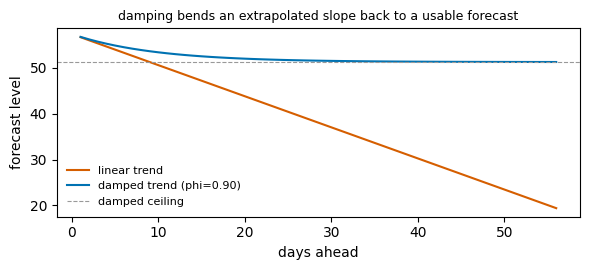

In [16]:
# the trend's multi-step behaviour is the whole story, so extrapolate the level component alone from the series' recent local slope
lvl0 = float(trend[-1]); b0 = float((trend[-1] - trend[-29]) / 28.0)          # recent slope (units/day) from the smoothed level
H = 56; hh = np.arange(1, H + 1); phi = 0.90
fc_lin = lvl0 + b0 * hh                                                       # local linear trend: slope persists forever
fc_damp = lvl0 + b0 * phi * (1 - phi ** hh) / (1 - phi)                       # damped trend: slope decays by phi each step
ceiling = lvl0 + b0 * phi / (1 - phi)
print('recent local slope %.2f units/day; extrapolated linearly that adds %.0f units over 8 weeks' % (b0, b0 * H))
print('linear-trend 8-week level %.0f vs damped (phi=0.90) %.0f -- damping caps the extrapolation at a ceiling of %.0f instead of marching on indefinitely'
      % (fc_lin[-1], fc_damp[-1], ceiling))
print('with phi<1 the geometric series phi+phi^2+... converges, so the forecast bends to a constant -- the standard guard against runaway long-horizon retail forecasts')
fig, ax = panel(1, 6.0, 2.8)
ax[0].plot(hh, fc_lin, color='#D55E00', label='linear trend'); ax[0].plot(hh, fc_damp, color='#0072B2', label='damped trend (phi=0.90)')
ax[0].axhline(ceiling, color='#999999', ls='--', lw=0.8, label='damped ceiling'); ax[0].set_xlabel('days ahead'); ax[0].set_ylabel('forecast level')
ax[0].legend(fontsize=8, frameon=False); ax[0].set_title('damping bends an extrapolated slope back to a usable forecast', fontsize=9)
plt.tight_layout(); plt.show()

## In short

- A state-space model is a hidden state evolving linearly with Gaussian noise, observed through noise; a vast
  range of time-series models is just a choice of the four matrices $T,Z,Q,H$, and the Kalman filter (predict-
  update, optimal gain) plus the RTS smoother do all the inference, yielding the exact likelihood for free.
- Structural models stack interpretable pieces -- level, trend, seasonal -- fit by maximising that likelihood
  and chosen by AIC; on real retail data the weekly seasonal is decisive, the trend marginal. Forecasts
  propagate the state covariance into honest, widening bands, and innovation diagnostics confirm the structure
  is captured.
- The same machinery is dynamic regression (time-varying coefficients a static model would average away),
  ARIMA (state-space form, fit via the Kalman likelihood -- mixle's `AR1`), nonlinear filtering (the
  ensemble Kalman filter, inverting a nonlinear observation), regime switching (a Hamilton filter recovering
  hidden volatility regimes), and missing-data interpolation at no extra cost.
- mixle's `LocalLevel` and `AR1` give the common cases in one line (verified against the from-scratch
  filter); the general recursion handles the rest. The toolkit runs forecasting, sensor fusion, finance, and
  control -- only $T,Z,Q,H$ change.

## References

- Kalman, R. E. (1960). A new approach to linear filtering and prediction problems. J. Basic Engineering, 82(1), 35-45.
- Durbin, J. & Koopman, S. J. (2012). Time Series Analysis by State Space Methods (2nd ed.). Oxford University Press.
- Harvey, A. C. (1989). Forecasting, Structural Time Series Models and the Kalman Filter. Cambridge University Press.
- Hamilton, J. D. (1989). A new approach to the economic analysis of nonstationary time series. Econometrica, 57(2), 357-384.
- Evensen, G. (2009). Data Assimilation: The Ensemble Kalman Filter (2nd ed.). Springer.
- Hyndman, R. J. & Athanasopoulos, G. (2021). Forecasting: Principles and Practice (3rd ed.). OTexts.

## Exercises and extensions

1. Multiple seasonality. Add a second seasonal block (annual, via Fourier harmonics) and show it captures the
   holiday surge the weekly block cannot.
2. Diffuse initialisation. Replace the large-variance prior with an exact diffuse initialisation and compare
   the early-sample likelihood.
3. Particle filter. Replace the EnKF with a particle filter for a strongly non-Gaussian observation and
   compare tracking accuracy and degeneracy.
4. Smooth regime probabilities. Add the backward (Kim) smoother to the Hamilton filter and compare smoothed
   vs filtered regime probabilities.
5. Stochastic volatility. Fit a state-space stochastic-volatility model (AR(1) log-variance) to a return
   series and forecast one-day-ahead volatility.